# Housing Market Simulation

This notebook runs a discrete-event housing market simulation and reconstructs
all analytics exclusively from the **event log**. Nine renters with modest
incomes compete for five houses; most cannot sustain rent indefinitely, so
eviction and re-bidding cycles dominate the dynamics.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../..").resolve()))

from core import (
    Agent,
    AgentIncomeReceived,
    AuctionClear,
    Bid,
    CompositeAgentPolicy,
    Event,
    Evicted,
    EventQueue,
    HomelessBiddingPolicy,
    House,
    HousingMarket,
    IncomePolicy,
    RentCollected,
    RentDue,
    RentStarted,
    SignalRegistry,
    SimulationEngine,
    SimulationSettings,
    VacantState,
)

import os
os.environ["DISABLE_PANDERA_IMPORT_WARNING"] = "True"

import pandas as pd
import pandera as pa
from pandera.typing import DataFrame, Series
import math
from typing import TypedDict
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")

## Market Setup

- **Landlord** owns all five houses and earns no external income (lives off rent).
- Nine renters (**Alice -- Ivy**) have modest incomes that, for most agents,
  fall short of covering rent. Each uses a composite policy that collects income
  and bids on vacant houses when homeless.
- Rent is paid every period; tenants who cannot pay are evicted. With four
  agents always homeless, competition for vacancies is constant.

In [ ]:
settings = SimulationSettings(vacancy_decay_rate=0.005)

owner_policy = IncomePolicy()
renter_policy = CompositeAgentPolicy(
    policies=(IncomePolicy(), HomelessBiddingPolicy())
)

landlord = Agent(
    id="landlord", money=100, income=0, spend_rate=0.0, policy=owner_policy,
)

renter_specs = [
    # (id,       money, income, spend_rate)
    ("alice",    10,     8,     0.60),
    ("bob",       5,     6,     0.70),
    ("carol",     8,     7,     0.65),
    ("dave",      7,     6,     0.60),
    ("eve",       4,     5,     0.75),
    ("frank",     9,     7,     0.62),
    ("grace",     3,     4,     0.80),
    ("hank",      6,     6,     0.68),
    ("ivy",       8,     7,     0.62),
]
renters = tuple(
    Agent(id=name, money=money, income=inc, spend_rate=sr, policy=renter_policy)
    for name, money, inc, sr in renter_specs
)

house_specs = [
    # (id,        rent, age)
    ("house_a",  10.0,  10),
    ("house_b",  15.0,   7),
    ("house_c",  20.0,   5),
    ("house_d",  25.0,   3),
    ("house_e",  35.0,   1),
]
houses = tuple(
    House(id=hid, owner_id="landlord", state=VacantState(), rent_price=rent, age=age)
    for hid, rent, age in house_specs
)

market = HousingMarket(
    entities=(landlord,) + renters + houses,
    settings=settings,
)

queue = EventQueue()
for agent in market.agents:
    queue = queue.push(AgentIncomeReceived(time=0, agent_id=agent.id))
queue = queue.push(AuctionClear(time=0))

engine = SimulationEngine(
    market=market, queue=queue, registry=SignalRegistry()
)

In [3]:
N_STEPS = 150_000
MAX_T = 800
sim = engine

for _ in range(N_STEPS):
    if not sim.queue.events:
        break
    sim = sim.step()
    if sim.now >= MAX_T:
        break

event_log = list(sim.event_log)
print(f"Processed {len(event_log)} events, simulation time reached t={sim.now}")

Processed 60200 events, simulation time reached t=800.0


## Analytics Layer

All downstream analysis is derived exclusively from the `event_log`.
We first materialise a single **fact table** (one row per event, warehouse-style)
validated by a pandera schema. Every visualisation is then a query against that
table -- no code ever touches the raw event objects again after the initial ETL.

In [4]:
class EventFact(pa.DataFrameModel):
    """One row per simulation event."""
    time: Series[float] = pa.Field(ge=0)
    event_type: Series[str]
    agent_id: Series[str] = pa.Field(nullable=True)
    house_id: Series[str] = pa.Field(nullable=True)
    amount: Series[float] = pa.Field(nullable=True)
    class Config:
        coerce = True

class WealthLog(pa.DataFrameModel):
    time: Series[float] = pa.Field(ge=0)
    agent: Series[str]
    money: Series[float]
    class Config:
        coerce = True

class OccupancyLog(pa.DataFrameModel):
    time: Series[float] = pa.Field(ge=0)
    house: Series[str]
    occupant: Series[str]
    class Config:
        coerce = True

class RentLog(pa.DataFrameModel):
    time: Series[float] = pa.Field(ge=0)
    house: Series[str]
    tenant: Series[str]
    amount: Series[float] = pa.Field(ge=0)
    class Config:
        coerce = True

class VacancyCount(pa.DataFrameModel):
    time: Series[float] = pa.Field(ge=0)
    n_vacant: Series[int] = pa.Field(ge=0)
    class Config:
        coerce = True

class TimeToRent(pa.DataFrameModel):
    time: Series[float] = pa.Field(ge=0)
    house: Series[str]
    duration: Series[float] = pa.Field(ge=0)
    class Config:
        coerce = True

class HouseRentLog(pa.DataFrameModel):
    time: Series[float] = pa.Field(ge=0)
    house: Series[str]
    rent: Series[float] = pa.Field(ge=0)
    class Config:
        coerce = True

In [5]:
class EventRow(TypedDict):
    time: float
    event_type: str
    agent_id: str | None
    house_id: str | None
    amount: float | None


def event_to_row(event: Event, agents: dict[str, Agent]) -> EventRow | None:
    """Convert a single simulation event to a flat fact-table row."""
    match event:
        case AgentIncomeReceived(time=t, agent_id=aid):
            a = agents[aid]
            return EventRow(time=t, event_type="income", agent_id=aid,
                            house_id=None, amount=a.income * (1 - a.spend_rate))
        case RentStarted(time=t, house_id=hid, tenant_id=tid):
            return EventRow(time=t, event_type="rent_started",
                            agent_id=tid, house_id=hid, amount=None)
        case RentCollected(time=t, house_id=hid, tenant_id=tid, amount=amt):
            return EventRow(time=t, event_type="rent_collected",
                            agent_id=tid, house_id=hid, amount=amt)
        case Evicted(time=t, house_id=hid, tenant_id=tid):
            return EventRow(time=t, event_type="evicted",
                            agent_id=tid, house_id=hid, amount=None)
        case Bid(time=t, agent_id=aid, house_id=hid, price=p):
            return EventRow(time=t, event_type="bid",
                            agent_id=aid, house_id=hid, amount=p)
        case AuctionClear(time=t):
            return EventRow(time=t, event_type="auction_clear",
                            agent_id=None, house_id=None, amount=None)
    return None


def build_fact_table(
    event_log: list[Event], initial_market: HousingMarket,
) -> DataFrame[EventFact]:
    """ETL: event objects -> validated fact table."""
    agents: dict[str, Agent] = {a.id: a for a in initial_market.agents}
    rows: list[EventRow] = [r for e in event_log if (r := event_to_row(e, agents)) is not None]
    df = pd.DataFrame(rows)
    return EventFact.validate(df.reset_index(drop=True))


# ---- projections (all derived from the fact table) ----

def project_wealth(
    facts: DataFrame[EventFact], initial_market: HousingMarket,
) -> DataFrame[WealthLog]:
    """Cumulative agent wealth via a signed-delta ledger, ffilled to every event time."""
    house_owners: dict[str, str] = {h.id: h.owner_id for h in initial_market.houses}
    event_times: list[float] = sorted(facts[EventFact.time].unique())

    inc: pd.DataFrame = (
        facts.query(f"{EventFact.event_type} == 'income'")
        [[EventFact.time, EventFact.agent_id, EventFact.amount]]
        .rename(columns={EventFact.agent_id: WealthLog.agent, EventFact.amount: "delta"})
    )

    rent: pd.DataFrame = facts.query(f"{EventFact.event_type} == 'rent_collected'")

    debits: pd.DataFrame = (
        rent[[EventFact.time, EventFact.agent_id, EventFact.amount]]
        .rename(columns={EventFact.agent_id: WealthLog.agent, EventFact.amount: "delta"})
        .assign(delta=lambda df: -df["delta"])
    )

    credits: pd.DataFrame = (
        rent[[EventFact.time, EventFact.house_id, EventFact.amount]]
        .assign(**{WealthLog.agent: lambda df: df[EventFact.house_id].map(house_owners)})
        .drop(columns=[EventFact.house_id])
        .rename(columns={EventFact.amount: "delta"})
    )

    initials: pd.DataFrame = pd.DataFrame({
        EventFact.time: [0.0] * len(initial_market.agents),
        WealthLog.agent: [a.id for a in initial_market.agents],
        "delta": [a.money for a in initial_market.agents],
    })

    return (
        pd.concat([initials, inc, debits, credits], ignore_index=True)
        .sort_values(EventFact.time, kind="mergesort")
        .assign(**{WealthLog.money: lambda df: df.groupby(WealthLog.agent)["delta"].cumsum()})
        .groupby([WealthLog.agent, EventFact.time])[WealthLog.money].last()
        .unstack(WealthLog.agent)
        .reindex(event_times).ffill()
        .rename_axis(columns=WealthLog.agent)
        .stack()
        .rename(WealthLog.money)
        .reset_index()
        .pipe(WealthLog.validate)
    )


def project_occupancy(
    facts: DataFrame[EventFact], initial_market: HousingMarket,
) -> DataFrame[OccupancyLog]:
    """House occupancy from rent_started / evicted events, ffilled to every event time."""
    event_times: list[float] = sorted(facts[EventFact.time].unique())

    starts: pd.DataFrame = (
        facts.query(f"{EventFact.event_type} == 'rent_started'")
        [[EventFact.time, EventFact.house_id, EventFact.agent_id]]
        .rename(columns={EventFact.house_id: OccupancyLog.house,
                         EventFact.agent_id: OccupancyLog.occupant})
    )

    evicts: pd.DataFrame = (
        facts.query(f"{EventFact.event_type} == 'evicted'")
        [[EventFact.time, EventFact.house_id]]
        .rename(columns={EventFact.house_id: OccupancyLog.house})
        .assign(**{OccupancyLog.occupant: "vacant"})
    )

    initials: pd.DataFrame = pd.DataFrame({
        EventFact.time: [0.0] * len(initial_market.houses),
        OccupancyLog.house: [h.id for h in initial_market.houses],
        OccupancyLog.occupant: [h.occupant_id() or "vacant" for h in initial_market.houses],
    })

    return (
        pd.concat([initials, starts, evicts], ignore_index=True)
        .sort_values(EventFact.time)
        .groupby([OccupancyLog.house, EventFact.time])[OccupancyLog.occupant].last()
        .unstack(OccupancyLog.house)
        .reindex(event_times).ffill()
        .rename_axis(columns=OccupancyLog.house)
        .stack()
        .rename(OccupancyLog.occupant)
        .reset_index()
        .pipe(OccupancyLog.validate)
    )


def project_rent_payments(
    facts: DataFrame[EventFact],
) -> DataFrame[RentLog]:
    return (
        facts.query(f"{EventFact.event_type} == 'rent_collected'")
        [[EventFact.time, EventFact.house_id, EventFact.agent_id, EventFact.amount]]
        .rename(columns={EventFact.house_id: RentLog.house,
                         EventFact.agent_id: RentLog.tenant})
        .reset_index(drop=True)
        .pipe(RentLog.validate)
    )


def project_vacancy_count(
    occupancy: DataFrame[OccupancyLog],
) -> DataFrame[VacancyCount]:
    return (
        occupancy
        .assign(is_vacant=lambda df: (df[OccupancyLog.occupant] == "vacant").astype(int))
        .groupby(OccupancyLog.time)["is_vacant"].sum()
        .rename(VacancyCount.n_vacant)
        .reset_index()
        .pipe(VacancyCount.validate)
    )


def project_time_to_rent(
    facts: DataFrame[EventFact], initial_market: HousingMarket,
) -> DataFrame[TimeToRent]:
    """Pair each vacancy start (eviction or t=0) with the next rent_started for the same house."""
    initial_vacant: pd.DataFrame = pd.DataFrame({
        "start": [0.0] * len(initial_market.houses),
        EventFact.house_id: [h.id for h in initial_market.houses],
    })

    vacancy_starts: pd.DataFrame = (
        pd.concat([
            initial_vacant,
            facts.query(f"{EventFact.event_type} == 'evicted'")
            [[EventFact.time, EventFact.house_id]]
            .rename(columns={EventFact.time: "start"}),
        ], ignore_index=True)
        .sort_values("start")
        .assign(rank=lambda df: df.groupby(EventFact.house_id).cumcount())
    )

    vacancy_ends: pd.DataFrame = (
        facts.query(f"{EventFact.event_type} == 'rent_started'")
        [[EventFact.time, EventFact.house_id]]
        .rename(columns={EventFact.time: "end"})
        .sort_values("end")
        .assign(rank=lambda df: df.groupby(EventFact.house_id).cumcount())
    )

    return (
        vacancy_starts.merge(vacancy_ends, on=[EventFact.house_id, "rank"])
        .assign(**{
            TimeToRent.time: lambda df: df["end"],
            TimeToRent.house: lambda df: df[EventFact.house_id],
            TimeToRent.duration: lambda df: df["end"] - df["start"],
        })
        [[TimeToRent.time, TimeToRent.house, TimeToRent.duration]]
        .pipe(TimeToRent.validate)
    )


def project_asking_rent(
    facts: DataFrame[EventFact],
    occupancy: DataFrame[OccupancyLog],
    initial_market: HousingMarket,
) -> DataFrame[HouseRentLog]:
    """Reconstruct each house's listed rent price over time.

    At each auction_clear: vacant houses that remain vacant decay by
    exp(-vacancy_decay_rate); houses that get rented adopt the clearing
    price (captured from the first rent_collected at the same time).
    """
    decay: float = math.exp(-initial_market.settings.vacancy_decay_rate)
    house_ids: list[str] = [h.id for h in initial_market.houses]
    rent: dict[str, float] = {h.id: h.rent_price for h in initial_market.houses}

    event_times: list[float] = sorted(occupancy[OccupancyLog.time].unique())
    auction_set: set[float] = set(
        facts.query(f"{EventFact.event_type} == 'auction_clear'")[EventFact.time]
    )
    evictions: dict[float, set[str]] = (
        facts.query(f"{EventFact.event_type} == 'evicted'")
        .groupby(EventFact.time)[EventFact.house_id]
        .apply(set)
        .to_dict()
    )

    started = facts.query(f"{EventFact.event_type} == 'rent_started'")[[EventFact.time, EventFact.house_id]]
    collected = facts.query(f"{EventFact.event_type} == 'rent_collected'")
    clearing = started.merge(collected, on=[EventFact.time, EventFact.house_id])
    clearing_prices: dict[tuple[float, str], float] = dict(
        zip(
            zip(clearing[EventFact.time], clearing[EventFact.house_id]),
            clearing[EventFact.amount],
        )
    )

    occ_wide: pd.DataFrame = occupancy.pivot_table(
        index=OccupancyLog.time, columns=OccupancyLog.house,
        values=OccupancyLog.occupant, aggfunc="last",
    )

    rows: list[dict] = []
    prev_vacant: set[str] = set(house_ids)

    for t in event_times:
        curr_vacant: set[str] = {
            hid for hid in house_ids if occ_wide.loc[t, hid] == "vacant"
        }

        if t in auction_set:
            was_vacant = prev_vacant | evictions.get(t, set())
            for hid in was_vacant & curr_vacant:
                rent[hid] *= decay
            for hid in was_vacant - curr_vacant:
                if (t, hid) in clearing_prices:
                    rent[hid] = clearing_prices[(t, hid)]

        for hid in house_ids:
            rows.append({
                HouseRentLog.time: t,
                HouseRentLog.house: hid,
                HouseRentLog.rent: rent[hid],
            })

        prev_vacant = curr_vacant

    return HouseRentLog.validate(pd.DataFrame(rows))

In [6]:
facts = build_fact_table(event_log, market)
print(f"Fact table:    {len(facts):>5} rows  |  {facts[EventFact.event_type].value_counts().to_dict()}")
print()

wealth_df = project_wealth(facts, market)
occupancy_df = project_occupancy(facts, market)
rent_df = project_rent_payments(facts)
vacancy_df = project_vacancy_count(occupancy_df)
ttr_df = project_time_to_rent(facts, market)
asking_rent_df = project_asking_rent(facts, occupancy_df, market)

print(f"Wealth log:    {len(wealth_df):>5} rows  |  {wealth_df[WealthLog.time].nunique()} unique times")
print(f"Occupancy log: {len(occupancy_df):>5} rows  |  {occupancy_df[OccupancyLog.time].nunique()} unique times")
print(f"Rent payments: {len(rent_df):>5} rows")
print(f"Vacancy count: {len(vacancy_df):>5} rows")
print(f"Time-to-rent:  {len(ttr_df):>5} rows")
print(f"Asking rent:   {len(asking_rent_df):>5} rows")

Fact table:    57828 rows  |  {'bid': 38722, 'income': 8001, 'auction_clear': 8001, 'rent_collected': 1643, 'rent_started': 732, 'evicted': 729}

Wealth log:     8010 rows  |  801 unique times
Occupancy log:  4005 rows  |  801 unique times
Rent payments:  1643 rows
Vacancy count:   801 rows
Time-to-rent:    732 rows
Asking rent:    4005 rows


## Visualizations

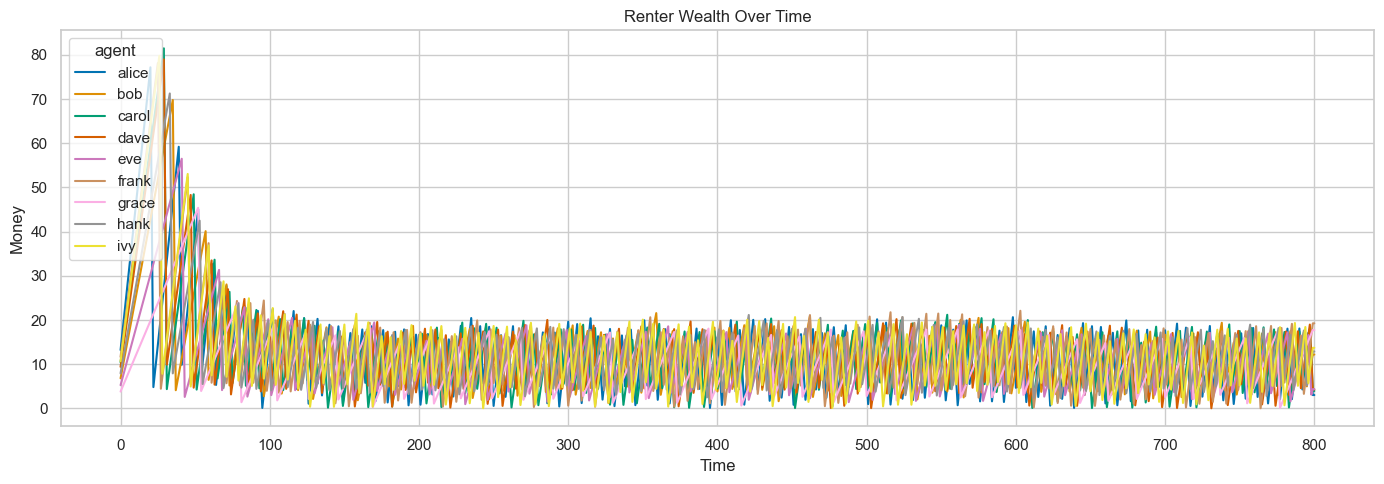

In [7]:
renter_wealth = wealth_df.query(f"{WealthLog.agent} != 'landlord'")

fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=renter_wealth, x=WealthLog.time, y=WealthLog.money, hue=WealthLog.agent, ax=ax)
ax.set_title("Renter Wealth Over Time")
ax.set_xlabel("Time")
ax.set_ylabel("Money")
sns.move_legend(ax, "upper left")
plt.tight_layout()
plt.show()

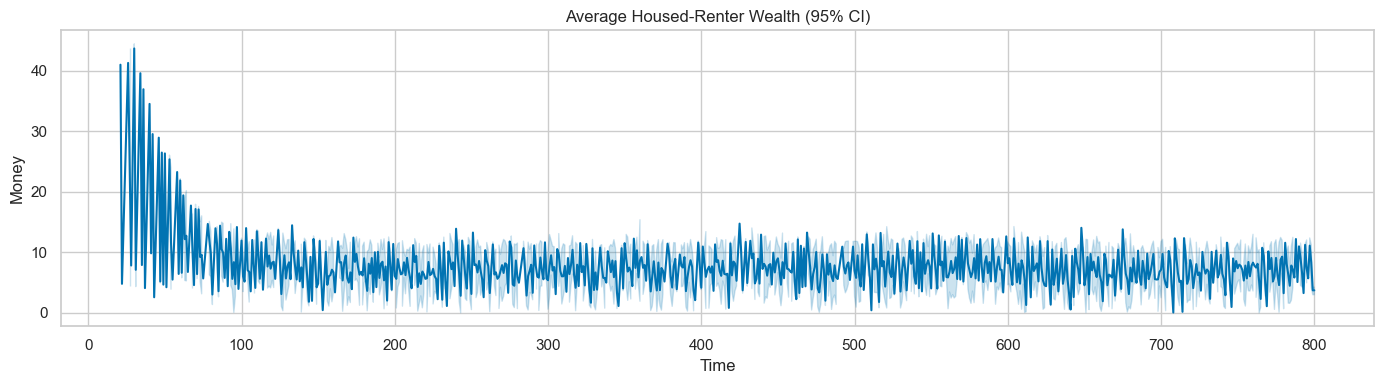

In [8]:
housed_agents = (
    occupancy_df
    .query(f"{OccupancyLog.occupant} != 'vacant'")
    [[OccupancyLog.time, OccupancyLog.occupant]]
    .rename(columns={OccupancyLog.time: WealthLog.time,
                     OccupancyLog.occupant: WealthLog.agent})
    .drop_duplicates()
)

housed_renter_wealth = (
    wealth_df
    .query(f"{WealthLog.agent} != 'landlord'")
    .merge(housed_agents, on=[WealthLog.time, WealthLog.agent])
)

fig, ax = plt.subplots(figsize=(14, 4))
sns.lineplot(data=housed_renter_wealth, x=WealthLog.time, y=WealthLog.money, ax=ax)
ax.set_title("Average Housed-Renter Wealth (95% CI)")
ax.set_xlabel("Time")
ax.set_ylabel("Money")
plt.tight_layout()
plt.show()

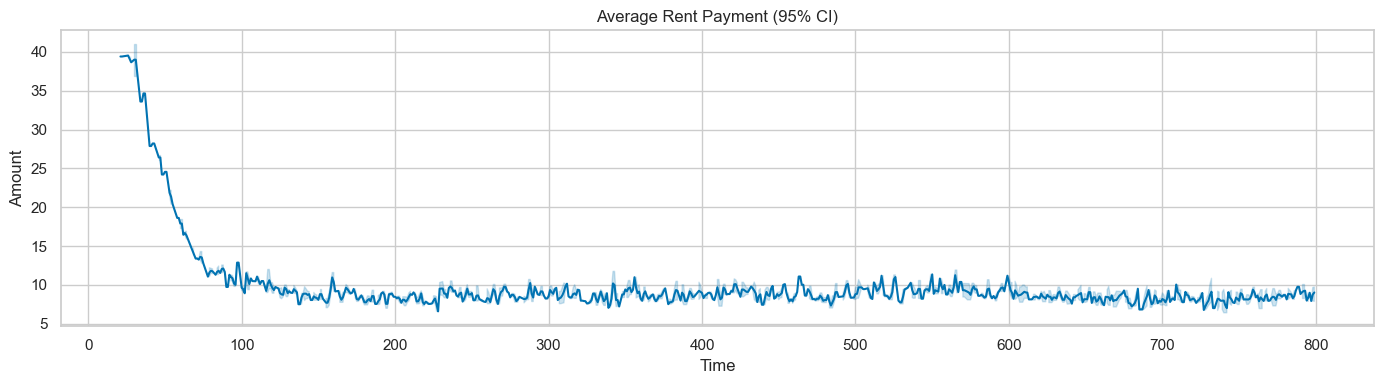

In [9]:
fig, ax = plt.subplots(figsize=(14, 4))
sns.lineplot(data=rent_df, x=RentLog.time, y=RentLog.amount, ax=ax)
ax.set_title("Average Rent Payment (95% CI)")
ax.set_xlabel("Time")
ax.set_ylabel("Amount")
plt.tight_layout()
plt.show()

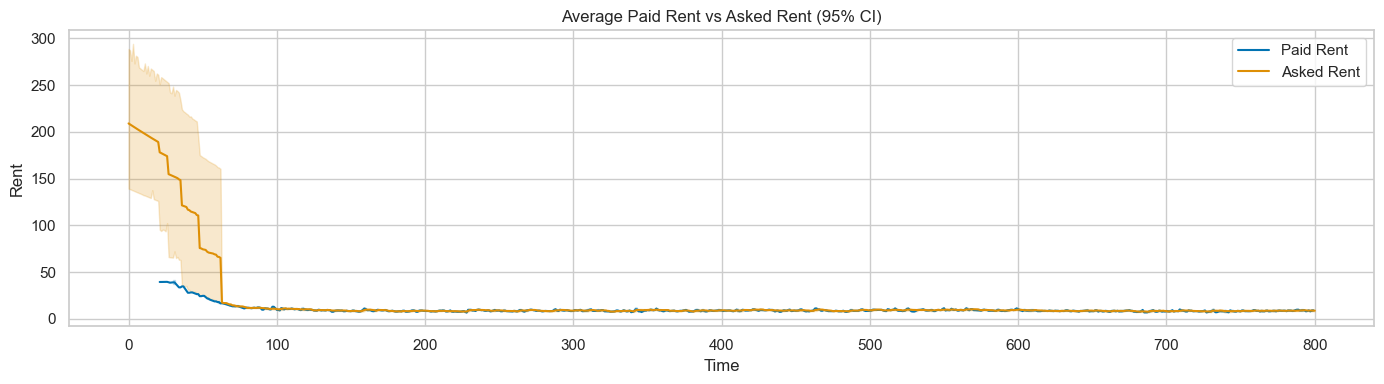

In [10]:
fig, ax = plt.subplots(figsize=(14, 4))
sns.lineplot(data=rent_df, x=RentLog.time, y=RentLog.amount, ax=ax, label="Paid Rent")
sns.lineplot(data=asking_rent_df, x=HouseRentLog.time, y=HouseRentLog.rent, ax=ax, label="Asked Rent")
ax.set_title("Average Paid Rent vs Asked Rent (95% CI)")
ax.set_xlabel("Time")
ax.set_ylabel("Rent")
ax.legend()
plt.tight_layout()
plt.show()

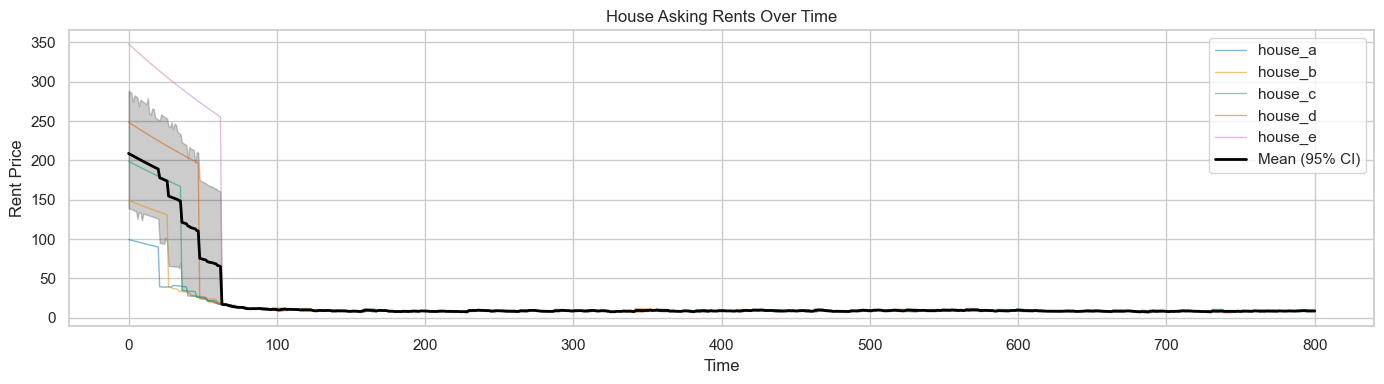

In [11]:
fig, ax = plt.subplots(figsize=(14, 4))
sns.lineplot(
    data=asking_rent_df, x=HouseRentLog.time, y=HouseRentLog.rent,
    hue=HouseRentLog.house, ax=ax, alpha=0.5, linewidth=1,
)
sns.lineplot(
    data=asking_rent_df, x=HouseRentLog.time, y=HouseRentLog.rent,
    ax=ax, color="black", linewidth=2, label="Mean (95% CI)",
)
ax.set_title("House Asking Rents Over Time")
ax.set_xlabel("Time")
ax.set_ylabel("Rent Price")
sns.move_legend(ax, "upper right")
plt.tight_layout()
plt.show()

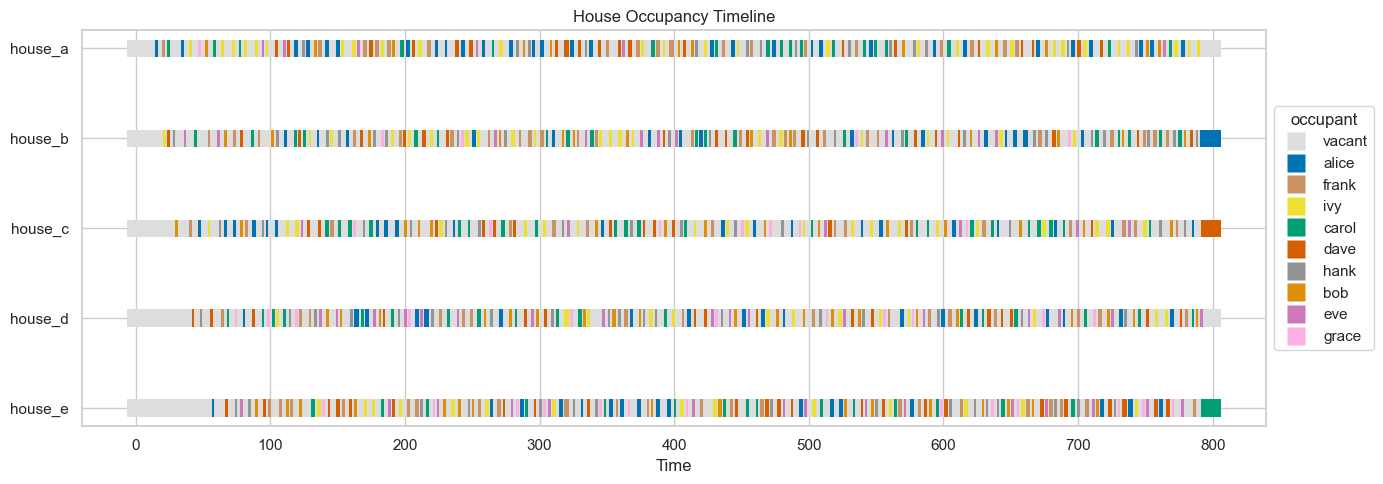

In [12]:
renter_names = sorted(
    occupancy_df
    .loc[occupancy_df[OccupancyLog.occupant] != "vacant", OccupancyLog.occupant]
    .unique()
)
palette = {"vacant": "#dddddd"}
palette.update({name: f"C{i}" for i, name in enumerate(renter_names)})

fig, ax = plt.subplots(figsize=(14, 5))
sns.scatterplot(
    data=occupancy_df,
    x=OccupancyLog.time, y=OccupancyLog.house, hue=OccupancyLog.occupant,
    palette=palette, s=160, marker="s", edgecolor="none", ax=ax,
)
ax.set_title("House Occupancy Timeline")
ax.set_xlabel("Time")
ax.set_ylabel("")
sns.move_legend(ax, "center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

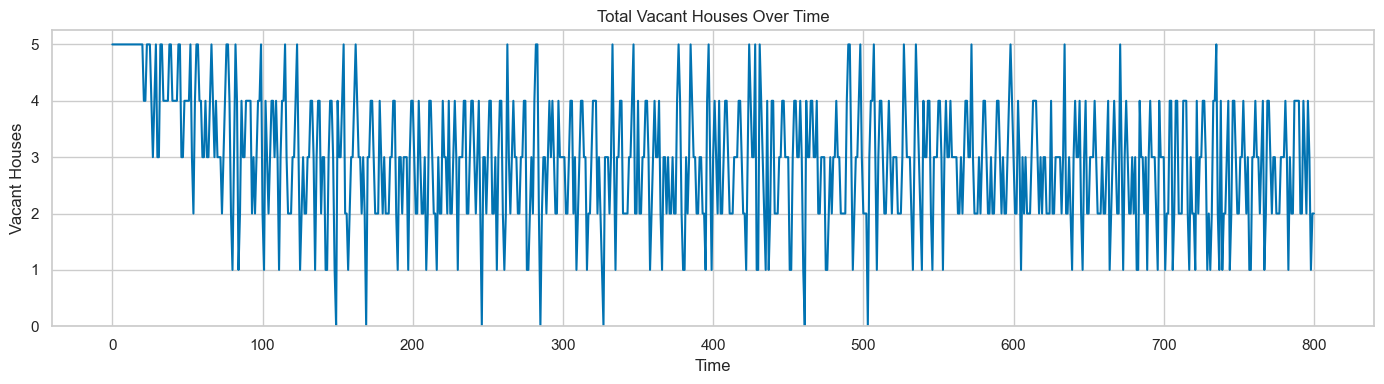

In [13]:
fig, ax = plt.subplots(figsize=(14, 4))
sns.lineplot(data=vacancy_df, x=VacancyCount.time, y=VacancyCount.n_vacant, ax=ax)
ax.set_title("Total Vacant Houses Over Time")
ax.set_xlabel("Time")
ax.set_ylabel("Vacant Houses")
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

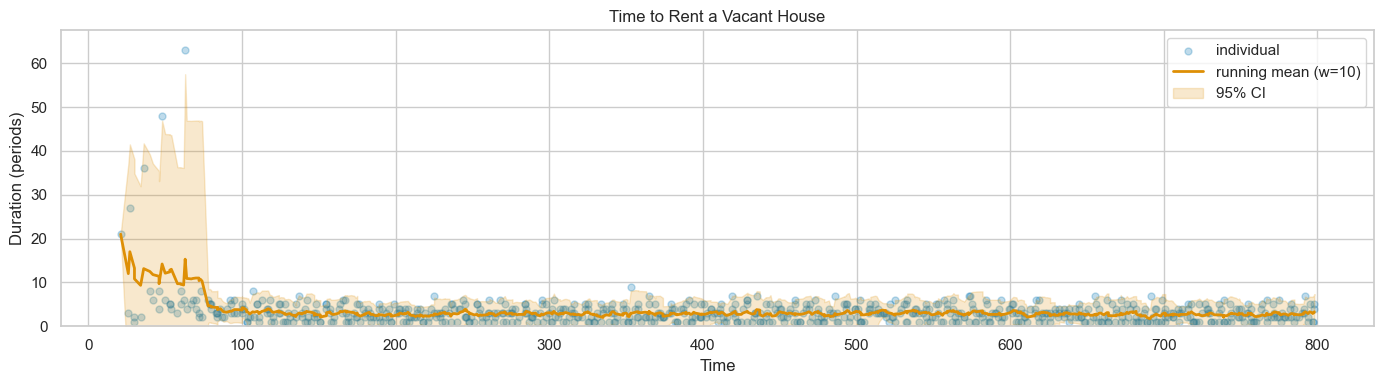

In [14]:
WINDOW = 10

ttr_sorted = ttr_df.sort_values(TimeToRent.time)
rolling = ttr_sorted[TimeToRent.duration].rolling(WINDOW, min_periods=1)
ttr_plot = ttr_sorted.assign(
    rolling_mean=rolling.mean(),
    rolling_std=rolling.std().fillna(0),
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.scatter(
    ttr_plot[TimeToRent.time], ttr_plot[TimeToRent.duration],
    alpha=0.25, s=25, color="C0", label="individual",
)
ax.plot(
    ttr_plot[TimeToRent.time], ttr_plot["rolling_mean"],
    color="C1", linewidth=2, label=f"running mean (w={WINDOW})",
)
ax.fill_between(
    ttr_plot[TimeToRent.time],
    ttr_plot["rolling_mean"] - 1.96 * ttr_plot["rolling_std"],
    ttr_plot["rolling_mean"] + 1.96 * ttr_plot["rolling_std"],
    alpha=0.2, color="C1", label="95% CI",
)
ax.set_title("Time to Rent a Vacant House")
ax.set_xlabel("Time")
ax.set_ylabel("Duration (periods)")
ax.legend()
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()